In [141]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import pickle
import warnings

In [114]:
def warn(*args,**kwargs):
    pass

warnings.warn = warn

In [115]:
df = pd.read_csv("../data/raw/01-bank-marketing-campaign-data.csv", sep=";")
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [116]:
df.info()
df.columns
df.describe().T
df.isna().sum()
df.value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

age  job          marital   education            default  housing  loan  contact    month  day_of_week  duration  campaign  pdays  previous  poutcome     emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  nr.employed  y  
39   blue-collar  married   basic.6y             no       no       no    telephone  may    thu          124       1         999    0         nonexistent   1.1          93.994          -36.4          4.855      5191.0       no     2
36   retired      married   unknown              no       no       no    telephone  jul    thu          88        1         999    0         nonexistent   1.4          93.918          -42.7          4.966      5228.1       no     2
27   technician   single    professional.course  no       no       no    cellular   jul    mon          331       2         999    0         nonexistent   1.4          93.918          -42.7          4.962      5228.1       no     2
47   technician   divorced  high.school          no       yes      no    cell

In [117]:
mask = df.duplicated(keep=False)
df[mask]
df = df.drop_duplicates()
df.isna().sum()


age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

# Analisis univariante 

### Categorico

11
0
1
2
3
4
5
6
7
8
9
10
12


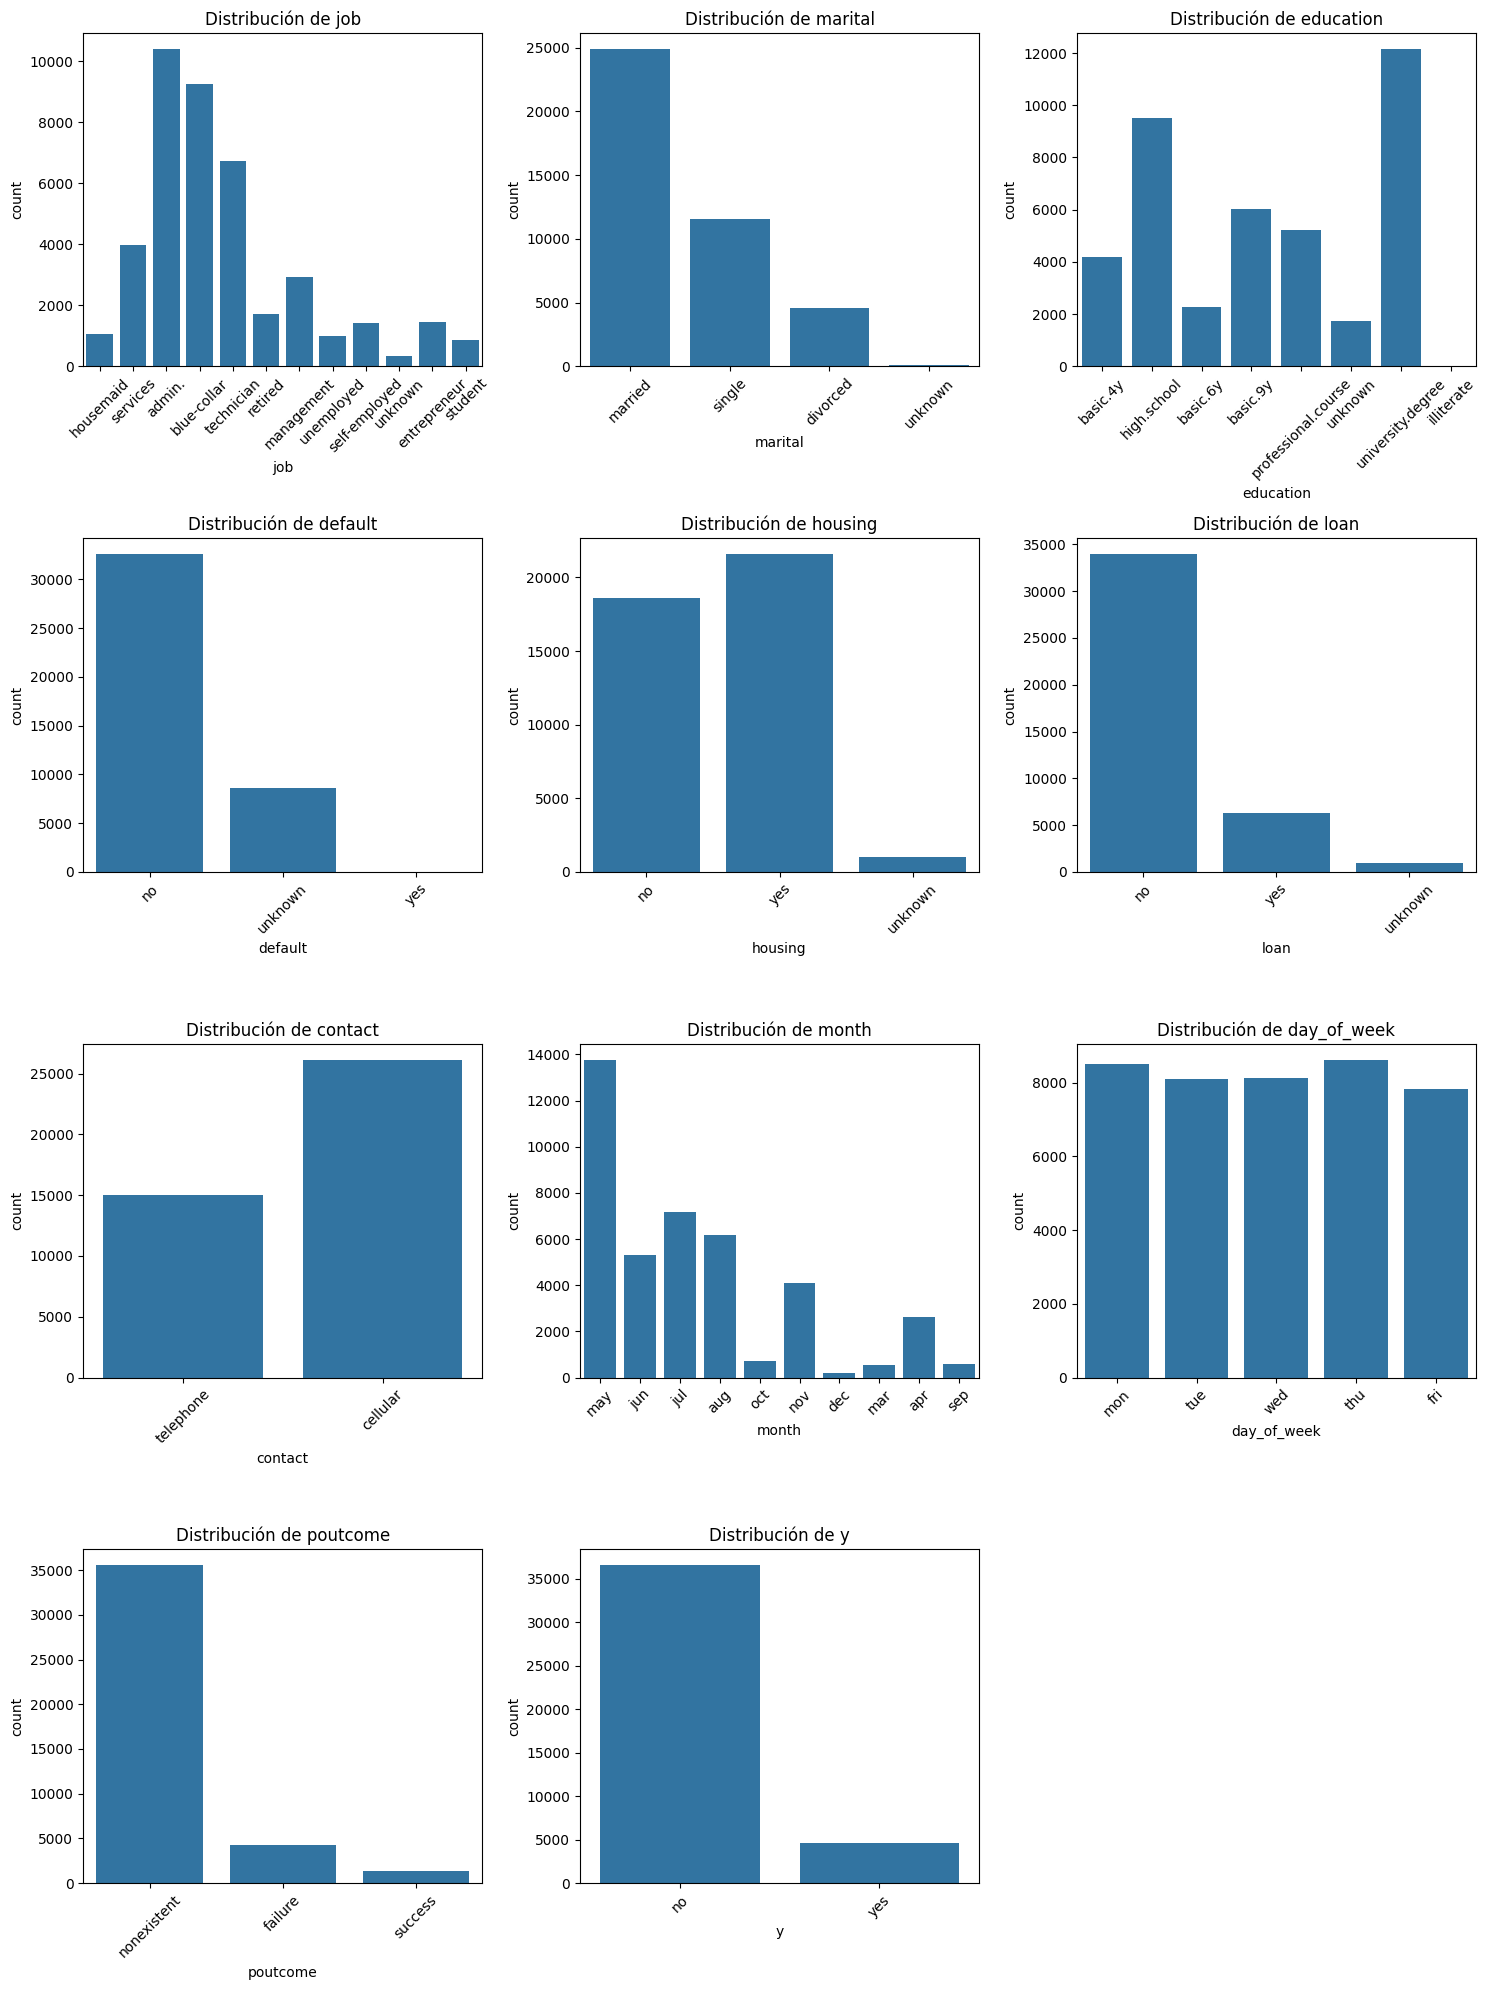

In [118]:
# Identificar columnas categóricas
categorical_cols = df.select_dtypes(include=['object']).columns

# Número de columnas categóricas
num_cols = len(categorical_cols)
print(num_cols)


fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 5 * 4))
axes = axes.flatten()  # Aplanar para fácil indexación

# Graficar cada columna categórica en un subplot
for i, col in enumerate(categorical_cols):
    print(i)
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'Distribución de {col}')
    axes[i].tick_params(axis='x', rotation=45)

print(len(axes))
for j in range(i + 1,len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### Conclusiones
-y: Los valores NO protagonizan nuestro dataset.Si esta es la variable a predecir tendremos que tomar en cuenta que nuestro modelo puede predecir correctamente el NO pero este "acierto" es inutil ya que queremos predecir el SI
-default: La mayoria de los valores son NO, significa que es un cliente ideal pero a nivel tecnico al no tener valores SI la columna no posee varianza y el modelo no puede aprender las diferencias entre un moroso y uno que no lo es
-loan: Observamos un poco mas de varianza.
-month: Observamos que mayo es el mes con mas actividad
-days: Poca varianza
-marital: cleintes mayormente casados y solteros
-education: clientes mayormente profesional y tecnico
-poutcome: clientes nuevos

In [119]:
df[df["education"] == "unknown"]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
10,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
26,59,technician,married,unknown,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
30,46,admin.,married,unknown,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
31,59,technician,married,unknown,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41118,34,technician,married,unknown,no,yes,no,cellular,nov,tue,...,2,999,2,failure,-1.1,94.767,-50.8,1.046,4963.6,no
41120,60,admin.,married,unknown,no,no,no,cellular,nov,tue,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.046,4963.6,no
41122,34,technician,married,unknown,no,no,no,cellular,nov,tue,...,3,999,0,nonexistent,-1.1,94.767,-50.8,1.046,4963.6,yes
41135,54,technician,married,unknown,no,yes,no,cellular,nov,thu,...,1,999,1,failure,-1.1,94.767,-50.8,1.041,4963.6,no


### Numerico

Número de columnas numéricas: 10


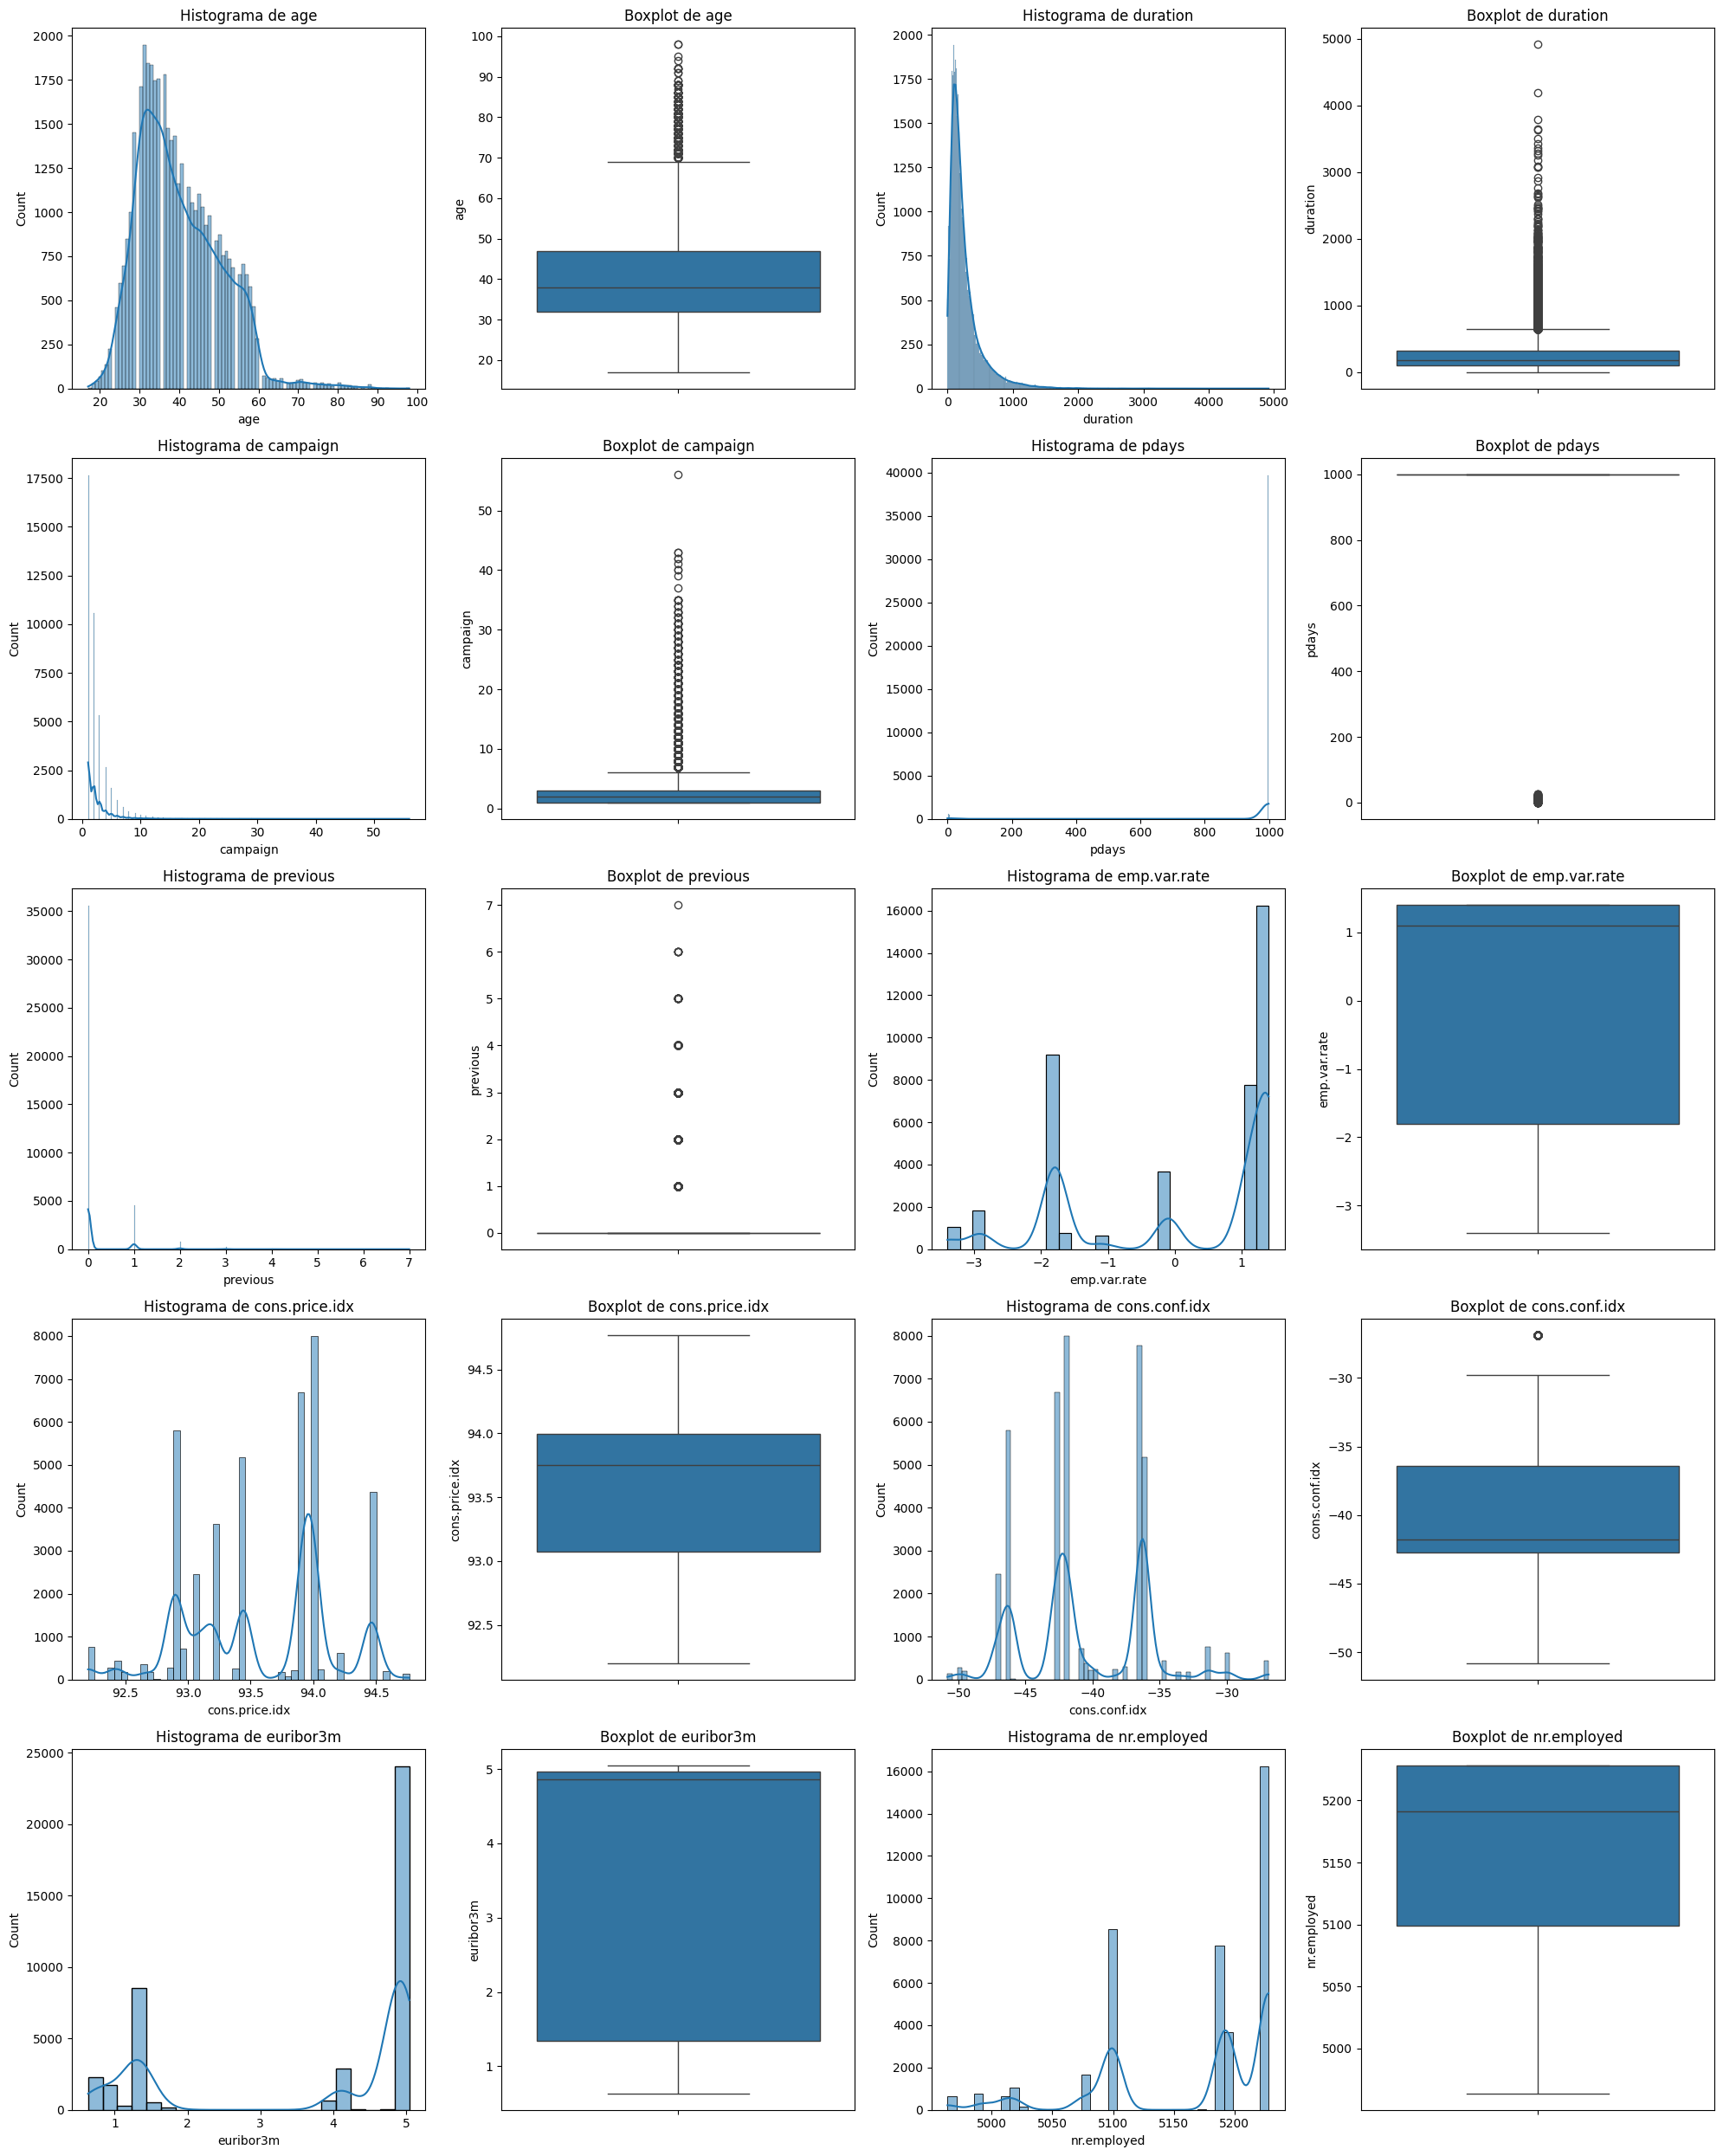

In [120]:
# Identificar columnas numéricas
numeric_cols = df.select_dtypes(include=['number']).columns

# Número de columnas numéricas
num_numeric = len(numeric_cols)
print(f"Número de columnas numéricas: {num_numeric}")

# Crear subplots con 4 columnas (hist1, box1, hist2, box2) y filas por pares de variables
ncols = 4
nrows = (num_numeric + 1) // 2  # Número de filas para pares

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 5 * nrows))

# Graficar para cada par de columnas numéricas
for row in range(nrows):
    for col_pair in range(2):
        idx = row * 2 + col_pair
        if idx >= num_numeric:
            # Ocultar subplots vacíos
            axes[row, col_pair * 2].set_visible(False)
            axes[row, col_pair * 2 + 1].set_visible(False)
            continue
        var = numeric_cols[idx]
        # Histplot en columna par
        sns.histplot(data=df, x=var, ax=axes[row, col_pair * 2], kde=True)
        axes[row, col_pair * 2].set_title(f'Histograma de {var}')
        # Boxplot en columna impar
        sns.boxplot(data=df, y=var, ax=axes[row, col_pair * 2 + 1])
        axes[row, col_pair * 2 + 1].set_title(f'Boxplot de {var}')

plt.tight_layout()
plt.show()

# Analisis Bivariante 

### Categorico

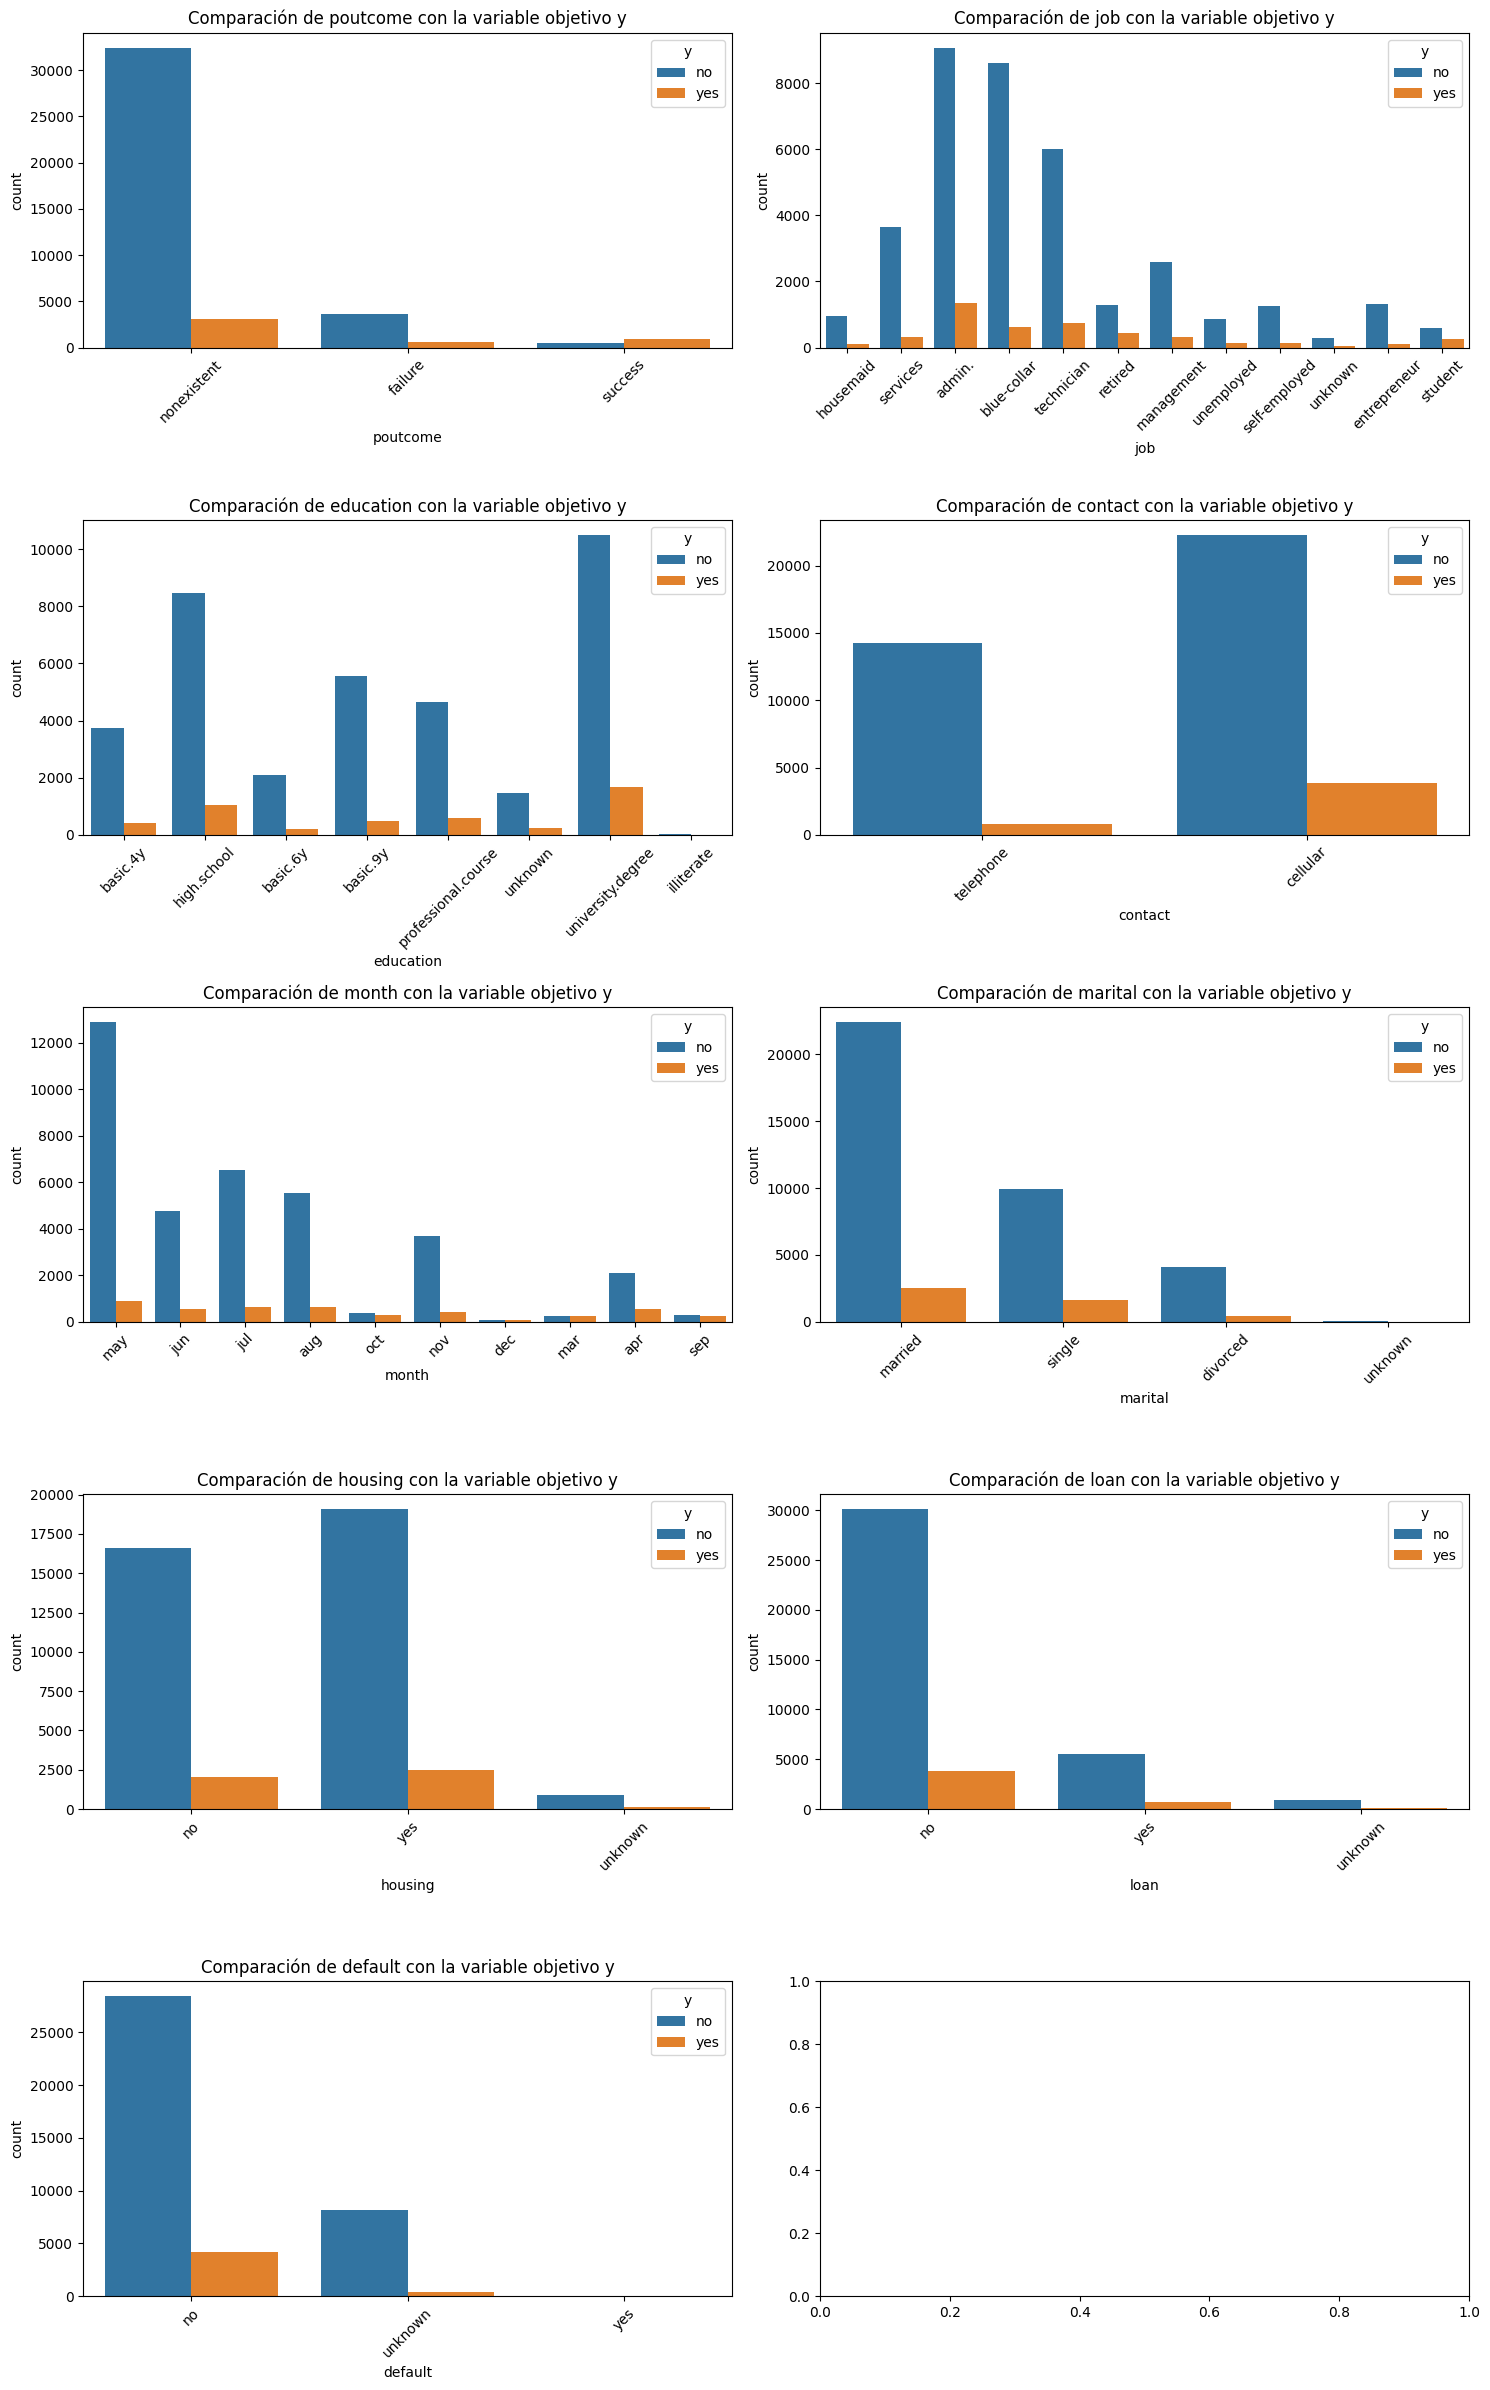

In [121]:
categorical_selected = ["poutcome","job","education","contact","month","marital","housing","loan","default"]

fig, axes = plt.subplots(5, 2, figsize=(15, 24))

for i, var in enumerate(categorical_selected):
    row = i // 2
    col = i % 2
    sns.countplot(data=df, x=var, hue="y", ax=axes[row, col])
    axes[row, col].set_title(f'Comparación de {var} con la variable objetivo y')
    axes[row, col].tick_params(axis='x', rotation=45)
    axes[row, col].legend(title='y')

plt.tight_layout()
plt.show()

### Numerico

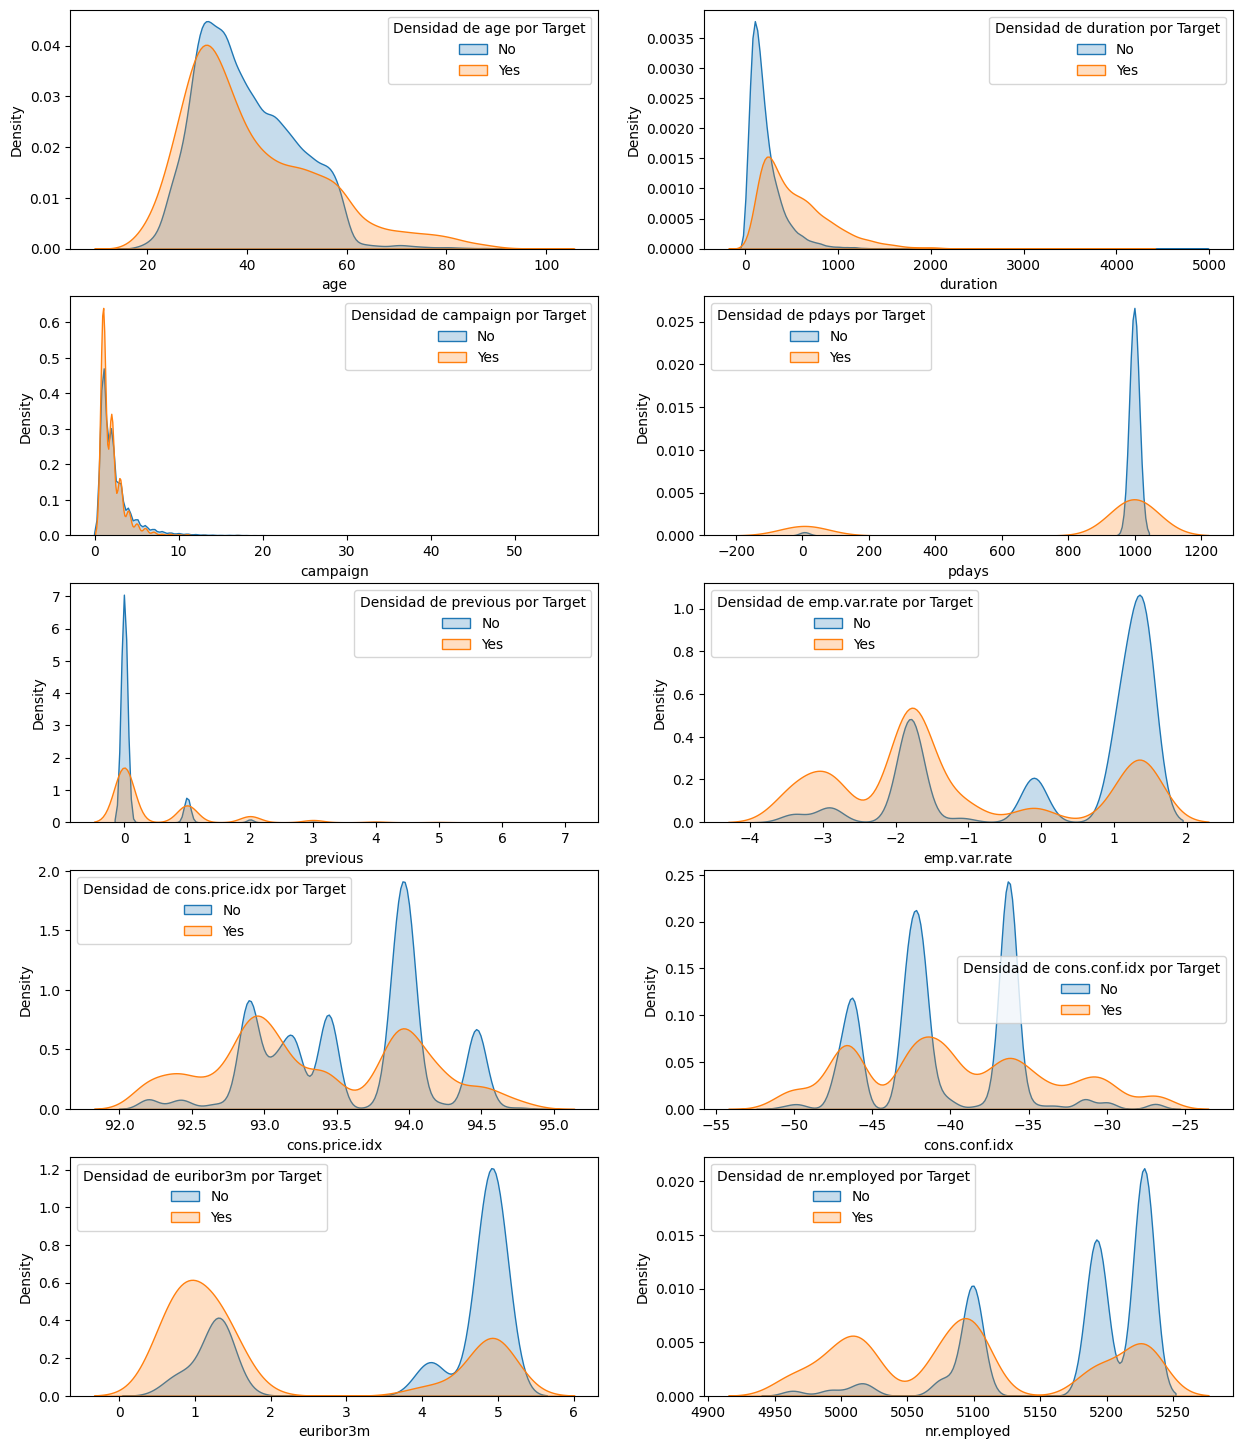

In [122]:
numeric_cols = df.select_dtypes(include=["number"]).columns

fig, axes = plt.subplots(5, 2, figsize=(15, 18))

for i, var in enumerate(numeric_cols):
    row = i // 2
    col = i % 2
    sns.kdeplot(data=df[df['y']=='no'][var], label='No', fill=True, ax=axes[row,col])
    sns.kdeplot(data=df[df['y']=='yes'][var], label='Yes', fill=True, ax=axes[row,col])
    
    axes[row, col].legend(title=f'Densidad de {var} por Target')
    
plt.show()


# Analisis Multivariante

### Numerico vs numerico

<Axes: >

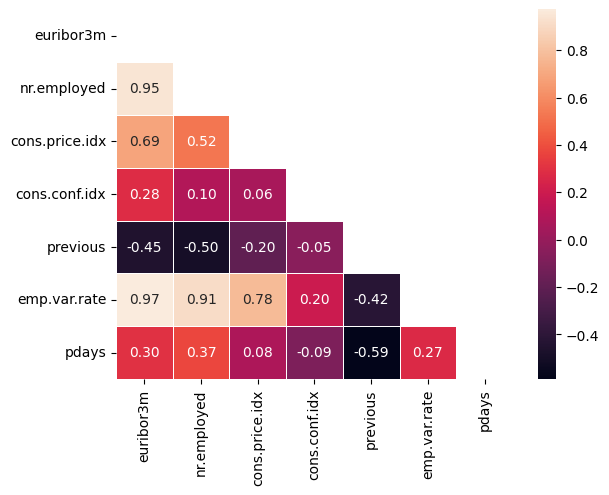

In [123]:
num_corr = df[["euribor3m","nr.employed","cons.price.idx","cons.conf.idx","previous","emp.var.rate","pdays"]].corr()
mask = np.triu(np.ones_like(num_corr, dtype=bool))
sns.heatmap(num_corr, mask=mask, annot=True, linewidths=0.5, fmt=".2f")



### Conclusiones
> Las variables economicas siguen siendo las mas relevantes, como podemos observar en el heatmap son las que pressentan mayor correlación, lo que indica que aportan las mismas pistas por lo que podemos quedarnos con una de ellas, pero lo vamos a hacer siguiendo dos criterios:
>> Separacion visual clara y facilidad de interpretacion, por lo que nos quedmaos con euribor3m

### Categorico vs categorico

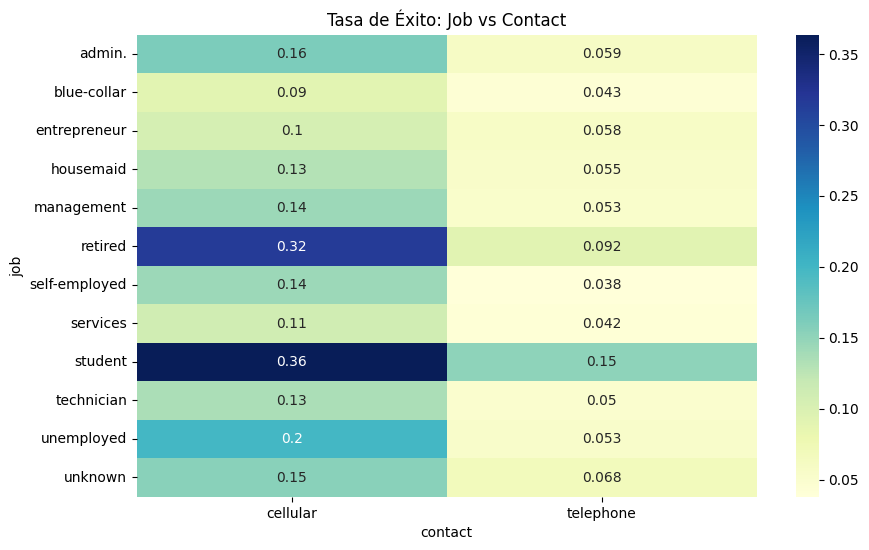

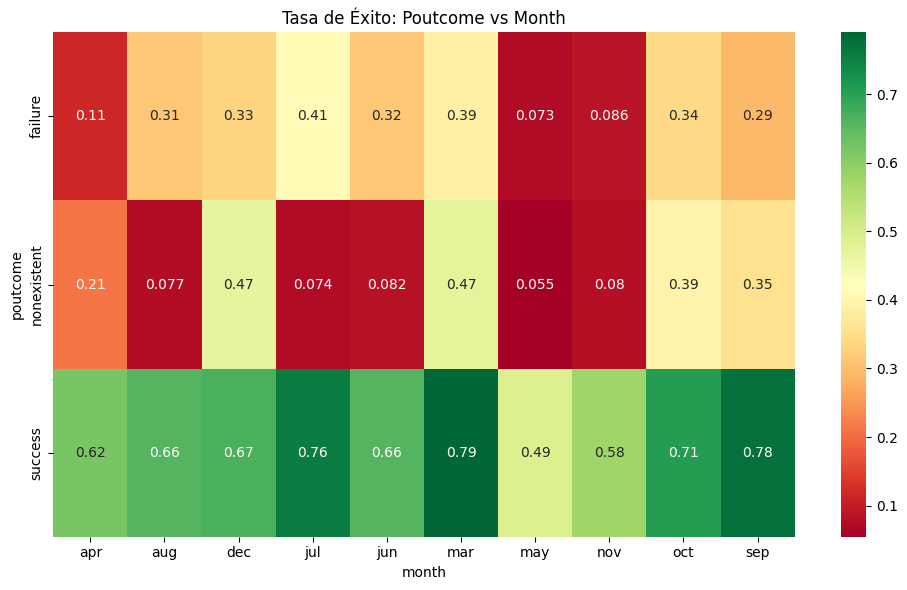

In [124]:
# Aseguramos que 'y' sea numérica para calcular la media 
df['y_binary'] = df['y'].map({'yes': 1, 'no': 0})


# Tabla de éxito por Trabajo y Medio de Contacto
plt.figure(figsize=(10, 6))
tabla_eficiencia = pd.crosstab(df['job'], df['contact'], values=df['y_binary'], aggfunc='mean')

sns.heatmap(tabla_eficiencia, annot=True, cmap='YlGnBu')
plt.title('Tasa de Éxito: Job vs Contact')


# Tabla de éxito por Resultado Anterior y Mes
plt.figure(figsize=(10, 6))
tabla_oro = pd.crosstab(df['poutcome'], df['month'], values=df['y_binary'], aggfunc='mean')

sns.heatmap(tabla_oro, annot=True, cmap='RdYlGn')
plt.title('Tasa de Éxito: Poutcome vs Month')


plt.tight_layout()
plt.show()

### Categorico vs numerico

--- PRUEBA DE DISCRIMINACIÓN (Medianas) ---
      age  duration  campaign  pdays  previous
y                                             
no   38.0     164.0       2.0  999.0       0.0
yes  37.0     449.0       2.0  999.0       0.0
---------------------------------------------


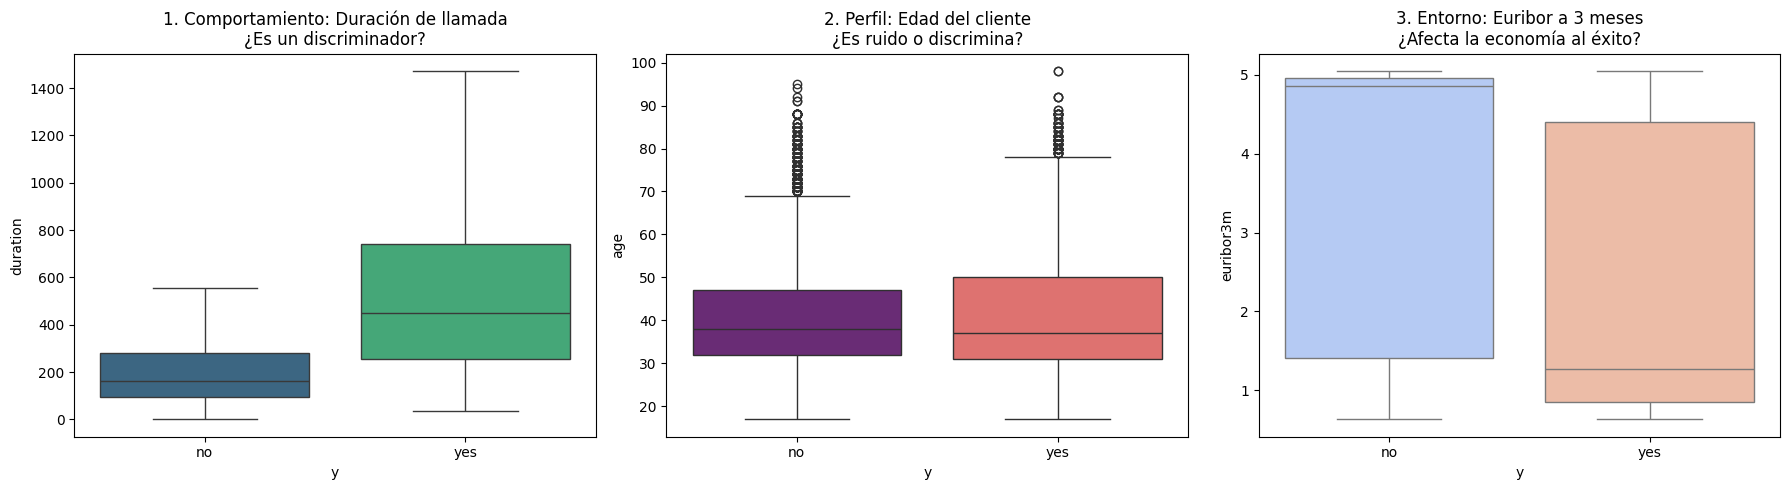

In [125]:
# Lista de variables numéricas candidatas
num_vars = ['age', 'duration', 'campaign', 'pdays', 'previous']

print("--- PRUEBA DE DISCRIMINACIÓN (Medianas) ---")
brecha_stats = df.groupby('y')[num_vars].median()
print(brecha_stats)
print("-" * 45)

# ==========================================
# PASO 2: LA EVIDENCIA VISUAL (Boxplots)
# ==========================================
# Creamos un lienzo con 3 gráficos para comparar 3 tipos de variables distintas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico A: El Comportamiento (duration) -> Ocultamos outliers (showfliers=False) para ver la caja limpia
sns.boxplot(data=df, x='y', y='duration', ax=axes[0], palette='viridis', showfliers=False)
axes[0].set_title('1. Comportamiento: Duración de llamada\n¿Es un discriminador?')

# Gráfico B: El Perfil (age)
sns.boxplot(data=df, x='y', y='age', ax=axes[1], palette='magma')
axes[1].set_title('2. Perfil: Edad del cliente\n¿Es ruido o discrimina?')

# Gráfico C: La Economía (euribor3m)
sns.boxplot(data=df, x='y', y='euribor3m', ax=axes[2], palette='coolwarm')
axes[2].set_title('3. Entorno: Euribor a 3 meses\n¿Afecta la economía al éxito?')

plt.tight_layout()
plt.show()

# Limpieza

##### pdays: Es una columna numerica que representa una etiqueta(ultima vez contactado). 999 significa clientes nunca contactados. Al ser un probelma de regresion logistica los valores de esta variable influirán mucho en el resultado, por eso la normalizamos de esta manera para deshacernos de esos valores que no nos interesan. Si usaramos un metodo de normalizacion como MinMaxScaler o RobustScaler el problema no se solucionaria, sino que se haria mas pequeño

In [126]:
df["pdays"].value_counts()

df["ultimo_contacto"] = pd.cut(df['pdays'], bins=[-1,7,15,27,1000], labels=[1,2,3,4])
df["ultimo_contacto"].value_counts()

ultimo_contacto
4    39661
1     1177
2      300
3       38
Name: count, dtype: int64

In [127]:
df["previous"].value_counts()

df["contactados_antes"] = pd.cut(df["previous"], bins=[-1,0,3,7], labels=[1,2,3])
df["contactados_antes"].value_counts()


contactados_antes
1    35551
2     5531
3       94
Name: count, dtype: int64

##### campaign: Ya que tenemos muchos valores atipicos en esta columna. Clientes que se les ha hecho mas de 10 llamadas vamos a aplicar una tecnica llamada clipping que consiste en marcar un "limite", en este caso decidimos que será 10, es decir, todos los clientes a los que se les llamo mas de 10 veces los vamos a juntar. 

In [128]:
df["campaign"].value_counts()
df["clipping_campaign"] = df["campaign"].clip(upper=10)
df["clipping_campaign"].value_counts()

clipping_campaign
1     17634
2     10568
3      5340
4      2650
5      1599
10     1094
6       979
7       629
8       400
9       283
Name: count, dtype: int64

### Dividir X e y

In [129]:
X = df.drop(["y","y_binary"], axis=1)
y = df["y_binary"]

In [130]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'y_binary',
       'ultimo_contacto', 'contactados_antes', 'clipping_campaign'],
      dtype='str')

# Seleccion de columnas

In [131]:
X = X.drop(["default","loan","housing","previous","pdays","campaign","cons.price.idx","emp.var.rate","nr.employed","duration","day_of_week"], axis=1, errors='ignore')

# split

In [132]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### separacion de categoricas y numericas

In [133]:
categorical_cols = X.select_dtypes(include="object").columns

X_train_categoricas = X_train[categorical_cols]
X_test_categoricas = X_test[categorical_cols]


numerical_cols = X.select_dtypes(exclude="object").columns

X_train_numericas = X_train[numerical_cols]
X_test_numericas = X_test[numerical_cols]

# Codificado

In [134]:
encoder = OneHotEncoder(handle_unknown="ignore",sparse_output=False, drop='first')

# Entrenamos con el TRAIN y transformamos ambos
X_train_cat_encoded = encoder.fit_transform(X_train_categoricas)
X_test_cat_encoded = encoder.transform(X_test_categoricas)

# Escalado

In [135]:
scaler = StandardScaler()

X_train_num_scaled = scaler.fit_transform(X_train_numericas)
X_test_num_scaled = scaler.transform(X_test_numericas)

# Unir en Matrices finales

In [136]:
nombres_categoricos = encoder.get_feature_names_out()

#CONVERTIMOS A DATAFRAME
#Train

X_train_num_df = pd.DataFrame(
    X_train_num_scaled, 
    columns=numerical_cols, 
    index=X_train_numericas.index
)

X_train_cat_df = pd.DataFrame(
    X_train_cat_encoded, 
    columns=nombres_categoricos, 
    index=X_train_categoricas.index
)

#Test

X_test_num_df = pd.DataFrame(
    X_test_num_scaled, 
    columns=numerical_cols, 
    index=X_test_numericas.index
)

# ¡OJO! Usamos los mismos 'nombres_categoricos' que sacamos del encoder
X_test_cat_df = pd.DataFrame(
    X_test_cat_encoded, 
    columns=nombres_categoricos, 
    index=X_test_categoricas.index
)
# Unimos las columnas de entrenamiento y test
X_train_final = pd.concat([X_train_num_df, X_train_cat_df], axis=1)
X_test_final = pd.concat([X_test_num_df, X_test_cat_df], axis=1)

X_train_final,X_test_final

(            age  cons.conf.idx  euribor3m  ultimo_contacto  contactados_antes  \
 36454 -1.532272      -0.062687  -1.357248         0.191821           2.434917   
 1233  -0.766955       0.887842   0.712567         0.191821          -0.394324   
 24111 -0.671290      -0.321922   0.361165         0.191821          -0.394324   
 15516 -0.192967      -0.473142   0.771326         0.191821          -0.394324   
 17916 -0.097303      -0.473142   0.773630         0.191821          -0.394324   
 ...         ...            ...        ...              ...                ...   
 33267 -1.340943      -1.229245  -1.340542         0.191821          -0.394324   
 22714 -0.479961       0.952651   0.775358         0.191821          -0.394324   
 6971  -0.766955       0.887842   0.715447         0.191821          -0.394324   
 18503 -0.575626      -0.473142   0.777662         0.191821          -0.394324   
 24790 -0.479961      -0.321922   0.308166         0.191821          -0.394324   
 
        clippi

# Modelado

In [139]:
# Creamos el modelo con "pesos balanceados"
model = LogisticRegression(max_iter=1000,class_weight='balanced')

# Entrenar
model.fit(X_train_final, y_train)

# Predicciones
y_pred_test = model.predict(X_test_final)
y_pred_train = model.predict(X_train_final)
y_pred_test, y_pred_train

(array([0, 1, 0, ..., 0, 0, 0], shape=(8236,)),
 array([1, 0, 0, ..., 0, 0, 0], shape=(32940,)))

# Metricas

In [140]:
def get_classifier_metrics(y_predict_test, y_test, y_predict_train, y_train, average='micro'):
    metrics_train = (accuracy_score(y_train, y_predict_train),
                     f1_score(y_train, y_predict_train, average=average),
                     precision_score(y_train, y_predict_train, average=average),
                     recall_score(y_train, y_predict_train, average=average))
    metrics_test = (accuracy_score(y_test, y_predict_test),
                    f1_score(y_test, y_predict_test, average=average),
                    precision_score(y_test, y_predict_test, average=average),
                    recall_score(y_test, y_predict_test, average=average))
    return pd.DataFrame(data=[metrics_train, metrics_test],
                        columns=['Accuracy', 'F1 Score', 'Precision', 'Recall'],
                        index=['Train set', 'Test set'])

result = get_classifier_metrics(y_pred_test,y_test,y_pred_train, y_train, average="binary")
result

,Accuracy,F1 Score,Precision,Recall
Train set,0.812902,0.433287,0.328867,0.634869
Test set,0.816537,0.448741,0.339217,0.662716


# Guardado

In [ ]:
#Guardamos
with open('/workspaces/Elreno23-machine-learning-python-template/src/logistic_regression_bank.pkl', 'wb') as file:
    pickle.dump(model, file)